<img src=https://i.imgur.com/WKQ0nH2.jpg height=350>

# Setup and Context


### Introduction

Welcome to Boston Massachusetts in the 1970s! Imagine you're working for a real estate development company. Your company wants to value any residential project before they start. You are tasked with building a model that can provide a price estimate based on a home's characteristics like:
* The number of rooms
* The distance to employment centres
* How rich or poor the area is
* How many students there are per teacher in local schools etc

<img src=https://i.imgur.com/WfUSSP7.png height=350>

To accomplish your task you will:

1. Analyse and explore the Boston house price data
2. Split your data for training and testing
3. Run a Multivariable Regression
4. Evaluate how your model's coefficients and residuals
5. Use data transformation to improve your model performance
6. Use your model to estimate a property price

###  Import Statements


In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

### Notebook Presentation

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

# Load the Data

The first column in the .csv file just has the row numbers, so it will be used as the index.

In [39]:
data = pd.read_csv('boston.csv', index_col=0)
data.columns = data.columns.str.upper()
data.rename(columns={"MEDV": "PRICE"}, inplace=True)

### Understand the Boston House Price Dataset

---------------------------

**Characteristics:**  

    :Number of Instances: 506

    :Number of Attributes: 13 numeric/categorical predictive. The Median Value (attribute 14) is the target.

    :Attribute Information (in order):
        1. CRIM     per capita crime rate by town
        2. ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        3. INDUS    proportion of non-retail business acres per town
        4. CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        5. NOX      nitric oxides concentration (parts per 10 million)
        6. RM       average number of rooms per dwelling
        7. AGE      proportion of owner-occupied units built prior to 1940
        8. DIS      weighted distances to five Boston employment centres
        9. RAD      index of accessibility to radial highways
        10. TAX      full-value property-tax rate per $10,000
        11. PTRATIO  pupil-teacher ratio by town
        12. B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
        13. LSTAT    % lower status of the population
        14. PRICE     Median value of owner-occupied homes in $1000's
        
    :Missing Attribute Values: None

    :Creator: Harrison, D. and Rubinfeld, D.L.

This is a copy of [UCI ML housing dataset](https://archive.ics.uci.edu/ml/machine-learning-databases/housing/). This dataset was taken from the StatLib library which is maintained at Carnegie Mellon University. You can find the [original research paper here](https://deepblue.lib.umich.edu/bitstream/handle/2027.42/22636/0000186.pdf?sequence=1&isAllowed=y).


# Preliminary Data Exploration

* What is the shape of `data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [40]:
data.shape

(506, 13)

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 506 entries, 0.00632 to 0.04741
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ZN       506 non-null    float64
 1   INDUS    506 non-null    float64
 2   CHAS     506 non-null    int64  
 3   NOX      506 non-null    float64
 4   RM       506 non-null    float64
 5   AGE      506 non-null    float64
 6   DIS      506 non-null    float64
 7   RAD      506 non-null    int64  
 8   TAX      506 non-null    int64  
 9   PTRATIO  506 non-null    float64
 10  B        506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  PRICE    506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 55.3 KB


## Data Cleaning - Check for Missing Values and Duplicates

In [42]:
data.isnull().values.any()

np.False_

In [43]:
data.duplicated().any()

np.False_

In [44]:
data.head()

,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
crim,,,,,,,,,,,,,
0.01,18.00,2.31,0,0.54,6.58,65.20,4.09,1,296,15.30,396.90,4.98,24.00
0.03,0.00,7.07,0,0.47,6.42,78.90,4.97,2,242,17.80,396.90,9.14,21.60
0.03,0.00,7.07,0,0.47,7.18,61.10,4.97,2,242,17.80,392.83,4.03,34.70
0.03,0.00,2.18,0,0.46,7.00,45.80,6.06,3,222,18.70,394.63,2.94,33.40
0.07,0.00,2.18,0,0.46,7.15,54.20,6.06,3,222,18.70,396.90,5.33,36.20


## Descriptive Statistics

* How many students are there per teacher on average?
* What is the average price of a home in the dataset?
* What is the `CHAS` feature?
* What are the minimum and the maximum value of the `CHAS` and why?
* What is the maximum and the minimum number of rooms per dwelling in the dataset?

In [45]:
data.PTRATIO.mean()

np.float64(18.455533596837945)

In [46]:
data.PRICE.mean()

np.float64(22.532806324110677)

In [47]:
print(data.RM.max())
data.RM.min()

8.78


3.561

In [48]:
data .describe()

,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.00,0.46,0.00,0.39,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.23,16.96,25.00
max,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


## Visualise the Features

Having looked at some descriptive statistics, visualise the data for your model. Use [Seaborn's `.displot()`](https://seaborn.pydata.org/generated/seaborn.displot.html#seaborn.displot) to create a bar chart and superimpose the Kernel Density Estimate (KDE) for the following variables:
* PRICE: The home price in thousands.
* RM: the average number of rooms per owner unit.
* DIS: the weighted distance to the 5 Boston employment centres i.e., the estimated length of the commute.
* RAD: the index of accessibility to highways.

Try setting the `aspect` parameter to `2` for a better picture.

What do you notice in the distributions of the data?

#### House Prices

Text(13.819444444444445, 0.5, 'Nr. of Homes')

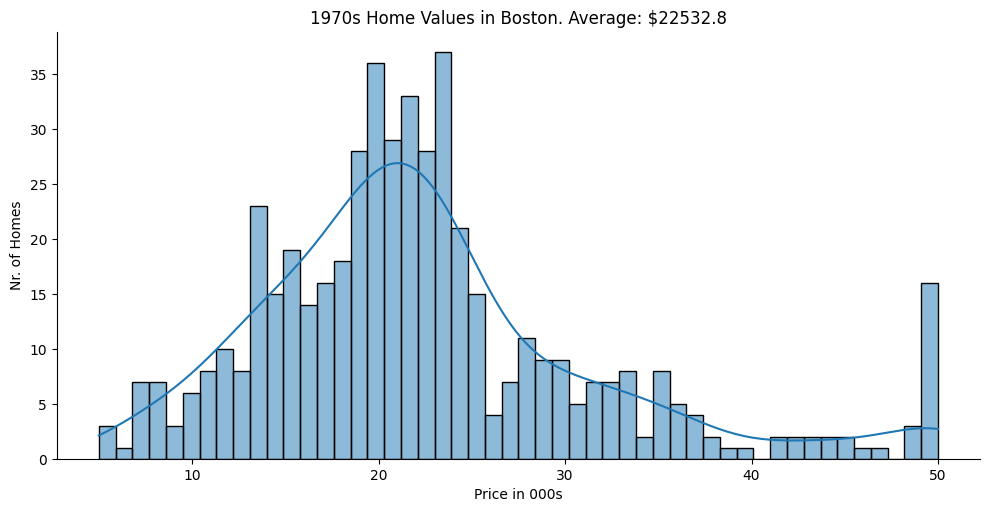

In [49]:
sns.displot(data=data, x="PRICE", kde=True, aspect=2,bins=50)
plt.title(f'1970s Home Values in Boston. Average: ${(1000*data.PRICE.mean()):.6}')
plt.xlabel('Price in 000s')
plt.ylabel('Nr. of Homes')

#### Distance to Employment - Length of Commute

Text(13.819444444444445, 0.5, 'Nr. of Homes')

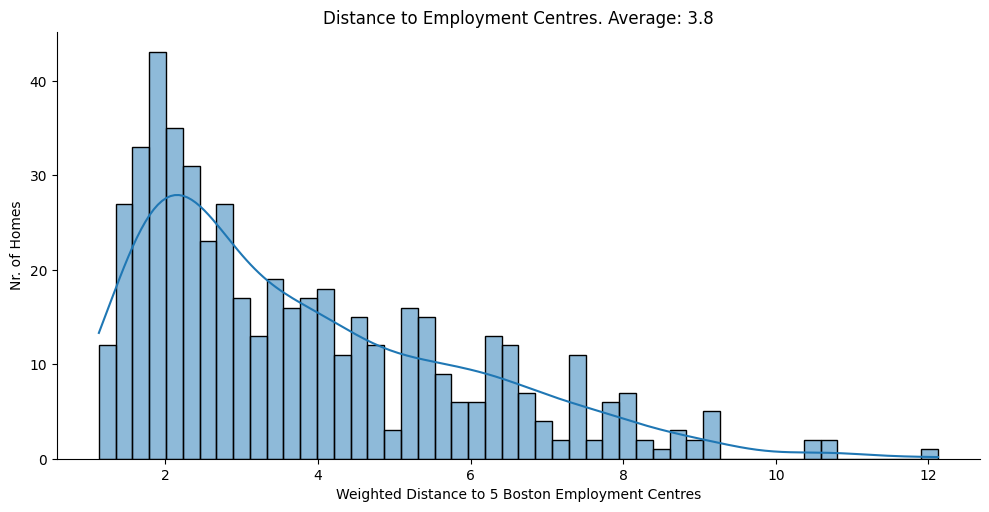

In [50]:
sns.displot(data=data, x="DIS", kde=True, aspect=2, bins=50)
plt.title(f'Distance to Employment Centres. Average: {(data.DIS.mean()):.2}')
plt.xlabel('Weighted Distance to 5 Boston Employment Centres')
plt.ylabel('Nr. of Homes')

#### Number of Rooms

Text(13.819444444444445, 0.5, 'Nr. of Homes')

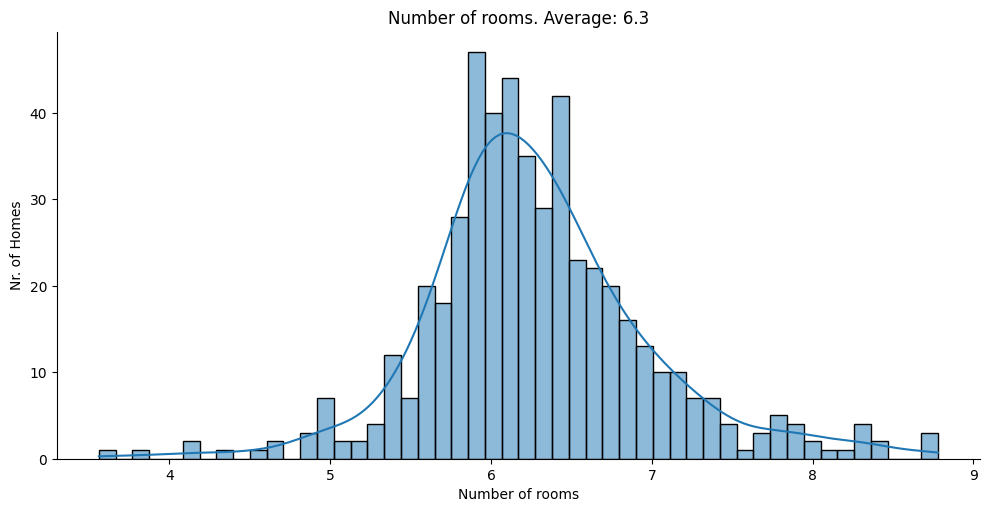

In [51]:
sns.displot(data=data, x="RM", kde=True, aspect=2,bins=50)
plt.title(f'Number of rooms. Average: {(data.RM.mean()):.2}')
plt.xlabel('Number of rooms')
plt.ylabel('Nr. of Homes')

#### Access to Highways

Text(0.5, 1.0, 'Access to highways: 9.5')

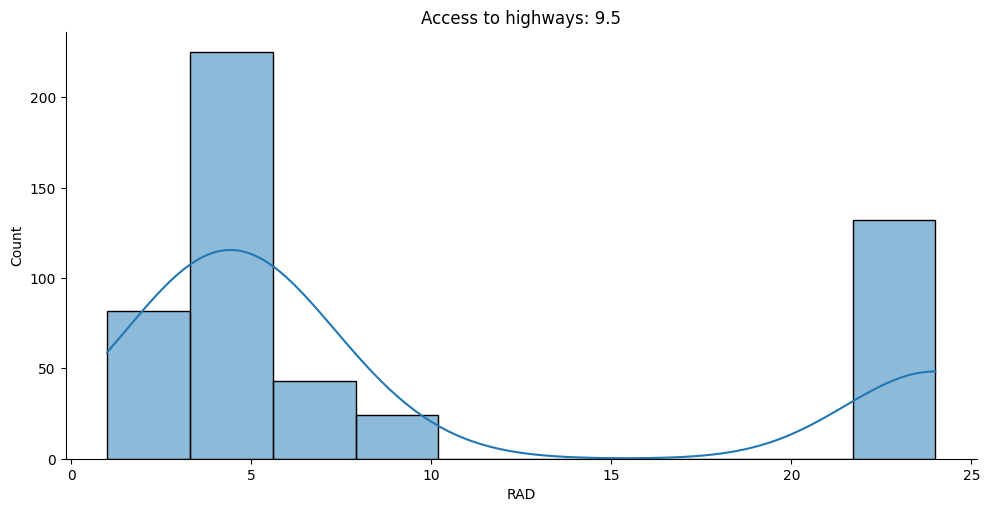

In [52]:
sns.displot(data=data, x="RAD", kde=True, aspect=2)
plt.title(f'Access to highways: {(data.RAD.mean()):.2}')


#### Next to the River?


Create a bar chart with plotly for CHAS to show many more homes are away from the river versus next to it. The bar chart should look something like this:

<img src=https://i.imgur.com/AHwoQ6l.png height=350>

You can make your life easier by providing a list of values for the x-axis (e.g., `x=['No', 'Yes']`)

In [53]:
river_access = data.CHAS.value_counts()


In [54]:
fig = px.bar(data, x=['No', 'Yes'], y=river_access.values, title='Next to Charles River?', color=river_access.values,
       labels={'x':'Property located next to river?',
               'y':'Number of homes'})
fig.update_layout(coloraxis_showscale=False)

<img src=https://i.imgur.com/b5UaBal.jpg height=350>

# Understand the Relationships in the Data

**Key Relationship: Income Proxy (LSTAT) vs Home Price**

#### % of Lower Income Population versus Home Price


Compare LSTAT with PRICE using Seaborn's `.jointplot()`. How does the proportion of the lower-income population in an area affect home prices?

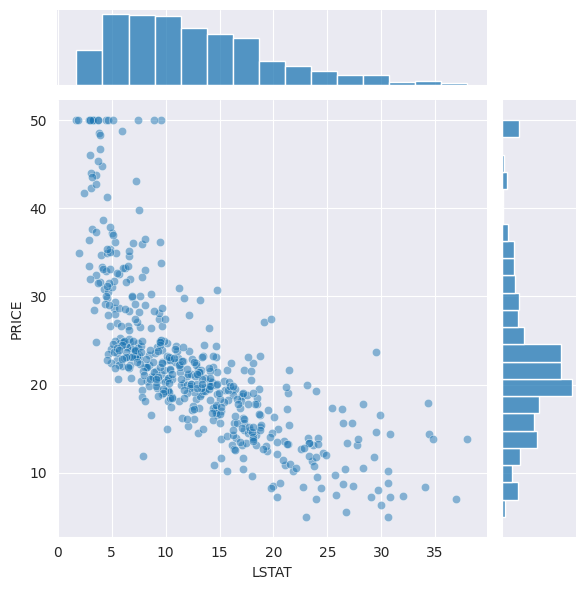

In [55]:
with sns.axes_style('darkgrid'):
  sns.jointplot(data, x="LSTAT", y="PRICE", joint_kws = dict(alpha=0.5))

**LSTAT vs PRICE**

1. Higher LSTAT (more lower-income population) is associated with lower home prices.

2. Relationship looks non-linear with stronger decline at higher LSTAT.

#### Number of Rooms versus Home Value

**Key Relationship: Rooms (RM) vs Home Price**

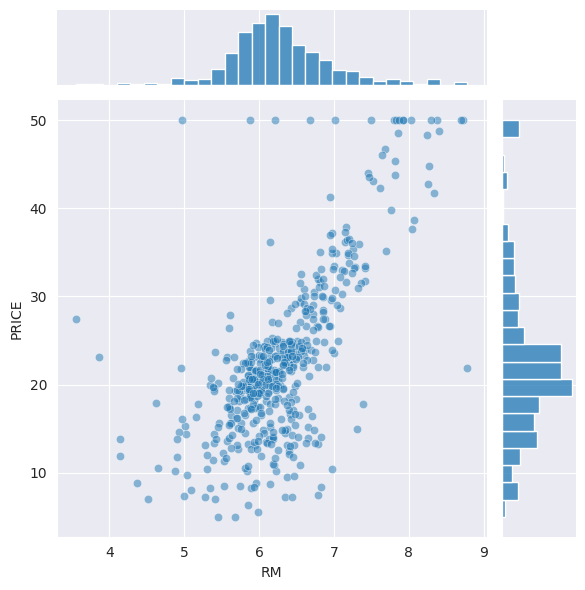

In [56]:
with sns.axes_style('darkgrid'):
  sns.jointplot(data, x="RM", y="PRICE", joint_kws = dict(alpha=0.5))

**RM vs PRICE**

1. More rooms (RM) generally correlates with higher home prices.

2. Some high-price outliers suggest other factors also drive valuation.

# Split Training & Test Dataset

We *can't* use all 506 entries in our dataset to train our model. The reason is that we want to evaluate our model on data that it hasn't seen yet (i.e., out-of-sample data). That way we can get a better idea of its performance in the real world.

* Import the [`train_test_split()` function](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) from sklearn
* Create 4 subsets: X_train, X_test, y_train, y_test
* Split the training and testing data roughly 80/20.
* To get the same random split every time you run your notebook use `random_state=10`. This helps us get the same results every time and avoid confusion while we're learning.


In [57]:
features = data.drop('PRICE', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    features, data.PRICE, test_size=0.2, random_state=10)


# Multivariable Regression

In a previous lesson, we had a linear model with only a single feature (our movie budgets). This time we have a total of 13 features. Therefore, our Linear Regression model will have the following form:

$$ PR \hat ICE = \theta _0 + \theta _1 RM + \theta _2 NOX + \theta _3 DIS + \theta _4 CHAS ... + \theta _{13} LSTAT$$

### Run Your First Regression

Use sklearn to run the regression on the training dataset. How high is the r-squared for the regression on the training data?

In [58]:

# Create linear regression object
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(X_train, y_train)

# Make predictions using the testing set
r_squared = regr.score(X_train, y_train)

In [59]:
print(f"Training data r-squared {r_squared}")

Training data r-squared 0.7398446249800801


### Evaluate the Coefficients of the Model

After fitting the multivariable linear regression model, I reviewed the learned coefficients to understand which features drive home prices and whether the directions match real-world intuition.

**How to read the coefficients**

1. Each coefficient represents the expected change in PRICE for a 1-unit increase in that feature while keeping all other variables constant.

2. A positive coefficient suggests higher predicted price as the feature increases; a negative coefficient suggests lower predicted price.

**Key observations (high-level)**

1. RM (average number of rooms) typically shows a positive coefficient, meaning homes with more rooms are predicted to be more valuable.

2. LSTAT (% lower-income population) typically shows a negative coefficient, indicating higher LSTAT is associated with lower predicted home values.

3. Features related to location/amenities (e.g., accessibility, pollution, taxes) often contribute smaller positive/negative effects, reflecting broader neighborhood quality and convenience factors.

Note on interpretation
Because this is a multivariable model, coefficients reflect the unique contribution of each feature after controlling for all others. This helps separate effects that may be correlated in the raw data (e.g., neighborhood characteristics).

In [61]:
df = pd.DataFrame({'Feature': features.columns,
                   'Coefficient': regr.coef_})
df

,Feature,Coefficient
0,ZN,0.06
1,INDUS,0.00
2,CHAS,2.20
3,NOX,-15.44
4,RM,3.15
5,AGE,0.02
6,DIS,-1.39
7,RAD,0.23
8,TAX,-0.01
9,PTRATIO,-0.81


In [62]:
premium_for_room = df.loc[df['Feature'] == 'RM'] *1000

premium_for_room.Coefficient

,Coefficient
4,"3,152.24"


### Analyse the Estimated Values & Regression Residuals

The next step is to evaluate our regression. How good our regression is depends not only on the r-squared. It also depends on the **residuals** - the difference between the model's predictions ($\hat y_i$) and the true values ($y_i$) inside `y_train`.

```
predicted_values = regr.predict(X_train)
residuals = (y_train - predicted_values)
```

Create two scatter plots.

The first plot should be actual values (`y_train`) against the predicted value values:

<img src=https://i.imgur.com/YMttBNV.png height=350>

The cyan line in the middle shows `y_train` against `y_train`. If the predictions had been 100% accurate then all the dots would be on this line. The further away the dots are from the line, the worse the prediction was. That makes the distance to the cyan line, you guessed it, our residuals


The second plot should be the residuals against the predicted prices. Here's what we're looking for:

<img src=https://i.imgur.com/HphsBsj.png height=350>



<>:6: SyntaxWarning:

invalid escape sequence '\h'

<>:8: SyntaxWarning:

invalid escape sequence '\h'

<>:6: SyntaxWarning:

invalid escape sequence '\h'

<>:8: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-906928083.py:6: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-906928083.py:8: SyntaxWarning:

invalid escape sequence '\h'



Text(0, 0.5, 'Prediced prices 000s $\\hat y _i$')

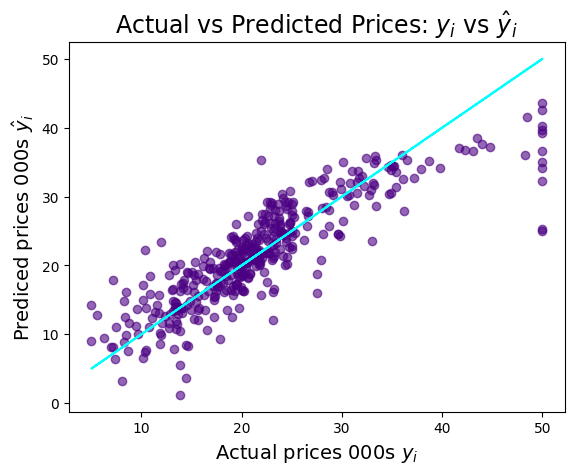

In [63]:
predicted_values = regr.predict(X_train)
residuals = (y_train - predicted_values)

plt.scatter(x=y_train, y=predicted_values, c='indigo', alpha=0.6)
plt.plot(y_train,y_train, color='cyan')
plt.title(f'Actual vs Predicted Prices: $y _i$ vs $\hat y_i$', fontsize=17)
plt.xlabel('Actual prices 000s $y _i$', fontsize=14)
plt.ylabel('Prediced prices 000s $\hat y _i$', fontsize=14)

<>:2: SyntaxWarning:

invalid escape sequence '\h'

<>:4: SyntaxWarning:

invalid escape sequence '\h'

<>:2: SyntaxWarning:

invalid escape sequence '\h'

<>:4: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-4261054177.py:2: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-4261054177.py:4: SyntaxWarning:

invalid escape sequence '\h'



Text(0.5, 0, 'Prediced prices 000s $\\hat y _i$')

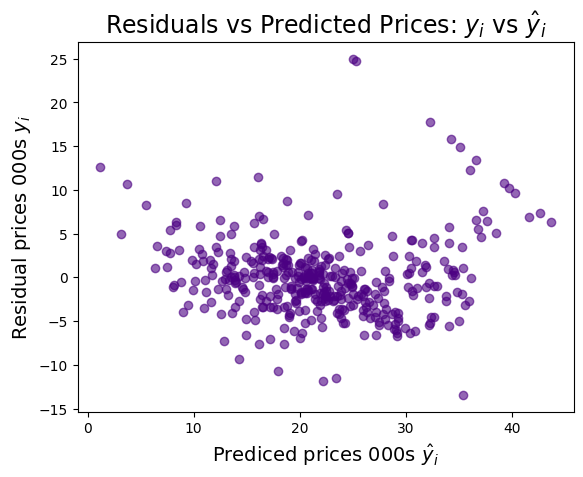

In [64]:
plt.scatter(x=predicted_values, y=residuals, c='indigo', alpha=0.6)
plt.title(f'Residuals vs Predicted Prices: $y _i$ vs $\hat y_i$', fontsize=17)
plt.ylabel('Residual prices 000s $y _i$', fontsize=14)
plt.xlabel('Prediced prices 000s $\hat y _i$', fontsize=14)

Why do we want to look at the residuals? We want to check that they look random. Why? The residuals represent the errors of our model. If there's a pattern in our errors, then our model has a systematic bias.

We can analyse the distribution of the residuals. In particular, we're interested in the **skew** and the **mean**.

In an ideal case, what we want is something close to a normal distribution. A normal distribution has a skewness of 0 and a mean of 0. A skew of 0 means that the distribution is symmetrical - the bell curve is not lopsided or biased to one side. Here's what a normal distribution looks like:

<img src=https://i.imgur.com/7QBqDtO.png height=400>

* Calculate the mean and the skewness of the residuals.
* Again, use Seaborn's `.displot()` to create a histogram and superimpose the Kernel Density Estimate (KDE)
* Is the skewness different from zero? If so, by how much?
* Is the mean different from zero?

In [65]:
resid_mean = round(residuals.mean(),2)
resid_skew = round(residuals.skew(),2)

Text(0.5, 1.0, 'Residuals Skew (1.38) Mean (0.0)')

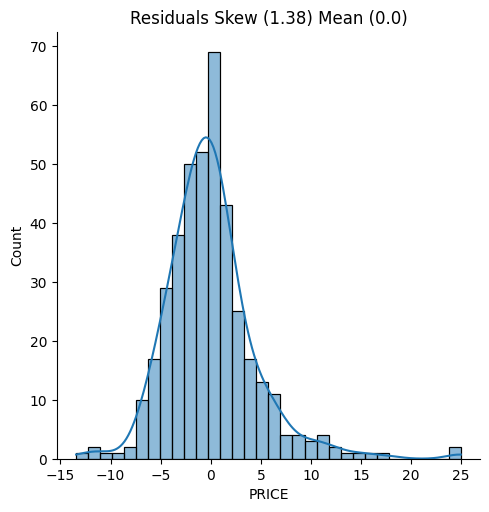

In [66]:
sns.displot(residuals, kde=True)
plt.title(f'Residuals Skew ({resid_skew}) Mean ({resid_mean})')

### Data Transformations for a Better Fit

We have two options at this point:

1. Change our model entirely. Perhaps a linear model is not appropriate.
2. Transform our data to make it fit better with our linear model.

Let's try a data transformation approach.

Investigate if the target `data['PRICE']` could be a suitable candidate for a log transformation.

* Use Seaborn's `.displot()` to show a histogram and KDE of the price data.
* Calculate the skew of that distribution.
* Use [NumPy's `log()` function](https://numpy.org/doc/stable/reference/generated/numpy.log.html) to create a Series that has the log prices
* Plot the log prices using Seaborn's `.displot()` and calculate the skew.
* Which distribution has a skew that's closer to zero?


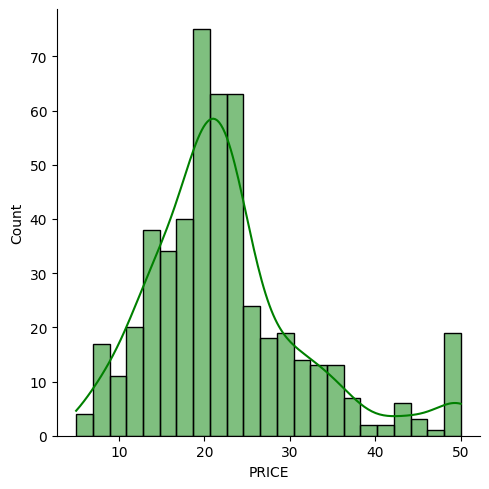

In [67]:
tgt_skew = data.PRICE.skew()
sns.displot(data.PRICE, kde='kde', color='green')

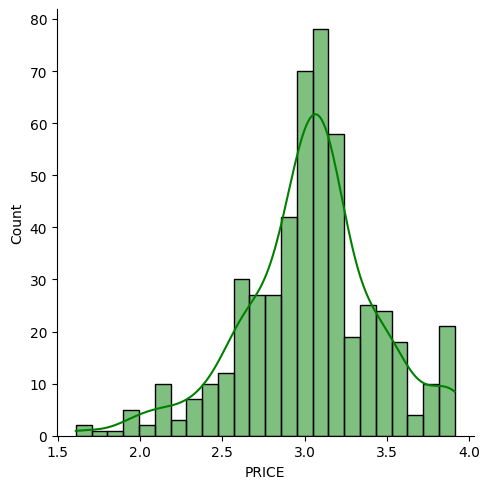

In [68]:
log_price = np.log(data.PRICE)
sns.displot(log_price, kde='kde', color='green')

#### How does the log transformation work?

Using a log transformation does not affect every price equally. Large prices are affected more than smaller prices in the dataset. Here's how the prices are "compressed" by the log transformation:

<img src=https://i.imgur.com/TH8sK1Q.png height=200>

We can see this when we plot the actual prices against the (transformed) log prices.

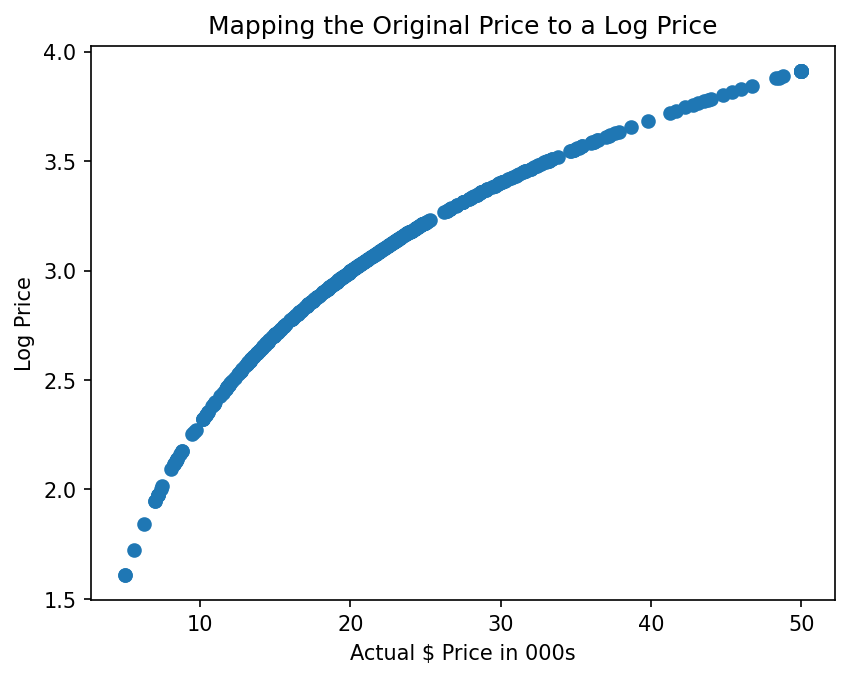

In [69]:
plt.figure(dpi=150)
plt.scatter(data.PRICE, np.log(data.PRICE))

plt.title('Mapping the Original Price to a Log Price')
plt.ylabel('Log Price')
plt.xlabel('Actual $ Price in 000s')
plt.show()

## Regression using Log Prices

Using log prices instead, our model has changed to:

$$ \log (PR \hat ICE) = \theta _0 + \theta _1 RM + \theta _2 NOX + \theta_3 DIS + \theta _4 CHAS + ... + \theta _{13} LSTAT $$

* Use `train_test_split()` with the same random state as before to make the results comparable.
* Run a second regression, but this time use the transformed target data.
* What is the r-squared of the regression on the training data?
* Have we improved the fit of our model compared to before based on this measure?


In [70]:
new_target = np.log(data['PRICE']) # Use log prices
features = data.drop('PRICE', axis=1)

X_train, X_test, log_y_train, log_y_test = train_test_split(features,
                                                    new_target,
                                                    test_size=0.2,
                                                    random_state=10)

log_regr = LinearRegression()
log_regr.fit(X_train, log_y_train)
log_rsquared = log_regr.score(X_train, log_y_train)

log_predictions = log_regr.predict(X_train)
log_residuals = (log_y_train - log_predictions)

print(f'Training data r-squared: {log_rsquared:.2}')

Training data r-squared: 0.76


## Evaluating Coefficients with Log Prices

Print out the coefficients of the new regression model.

* Do the coefficients still have the expected sign?
* Is being next to the river a positive based on the data?
* How does the quality of the schools affect property prices? What happens to prices as there are more students per teacher?

In [71]:
log_df = pd.DataFrame({'Feature': features.columns,
                   'Coefficient': log_regr.coef_})
log_df

,Feature,Coefficient
0,ZN,0.00
1,INDUS,0.00
2,CHAS,0.10
3,NOX,-0.63
4,RM,0.08
5,AGE,0.00
6,DIS,-0.04
7,RAD,0.01
8,TAX,-0.00
9,PTRATIO,-0.03


## Regression with Log Prices & Residual Plots

* Copy-paste the cell where you've created scatter plots of the actual versus the predicted home prices as well as the residuals versus the predicted values.
* Add 2 more plots to the cell so that you can compare the regression outcomes with the log prices side by side.
* Use `indigo` as the colour for the original regression and `navy` for the color using log prices.

<>:4: SyntaxWarning:

invalid escape sequence '\h'

<>:6: SyntaxWarning:

invalid escape sequence '\h'

<>:13: SyntaxWarning:

invalid escape sequence '\h'

<>:15: SyntaxWarning:

invalid escape sequence '\h'

<>:21: SyntaxWarning:

invalid escape sequence '\h'

<>:28: SyntaxWarning:

invalid escape sequence '\h'

<>:4: SyntaxWarning:

invalid escape sequence '\h'

<>:6: SyntaxWarning:

invalid escape sequence '\h'

<>:13: SyntaxWarning:

invalid escape sequence '\h'

<>:15: SyntaxWarning:

invalid escape sequence '\h'

<>:21: SyntaxWarning:

invalid escape sequence '\h'

<>:28: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-2550201402.py:4: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-2550201402.py:6: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-2550201402.py:13: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-2550201402.py:15: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-2550201402.py:21: S

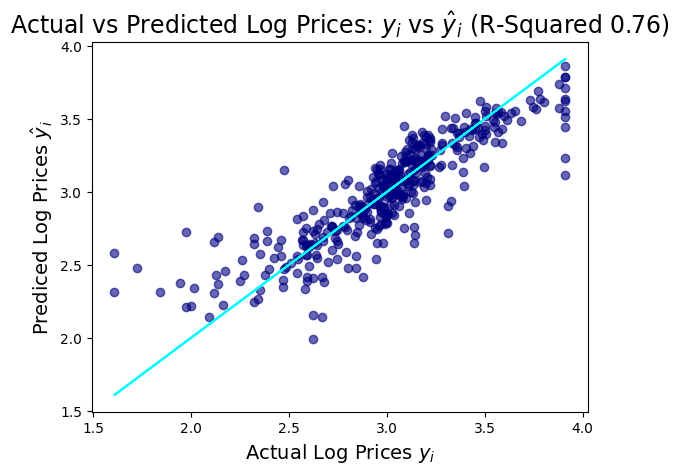

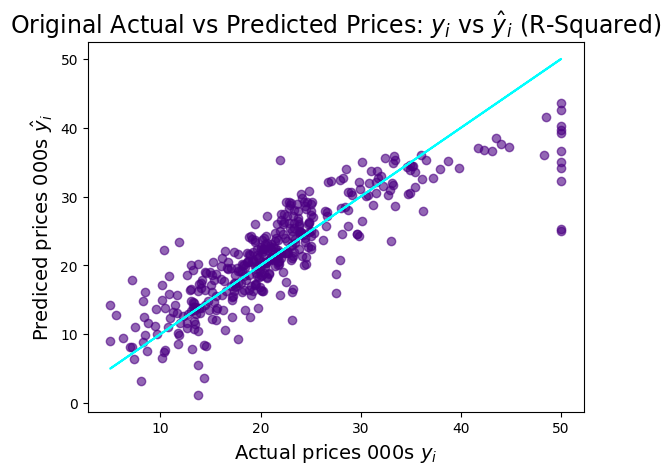

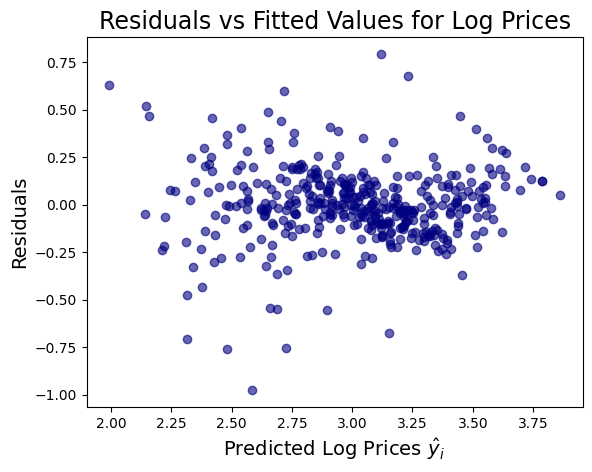

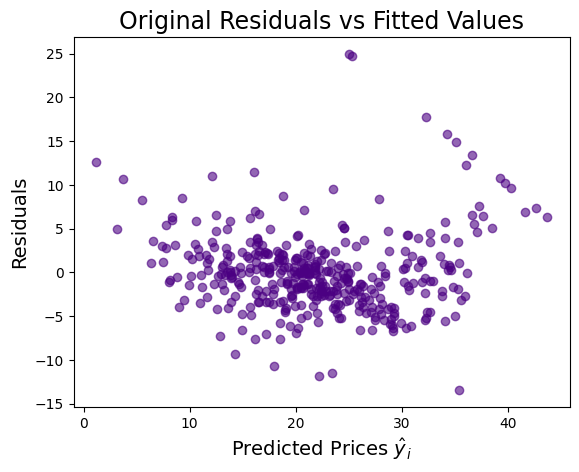

In [72]:
# Graph of Actual vs. Predicted Log Prices
plt.scatter(x=log_y_train, y=log_predictions, c='navy', alpha=0.6)
plt.plot(log_y_train, log_y_train, color='cyan')
plt.title(f'Actual vs Predicted Log Prices: $y _i$ vs $\hat y_i$ (R-Squared {log_rsquared:.2})', fontsize=17)
plt.xlabel('Actual Log Prices $y _i$', fontsize=14)
plt.ylabel('Prediced Log Prices $\hat y _i$', fontsize=14)
plt.show()

# Original Regression of Actual vs. Predicted Prices

plt.scatter(x=y_train, y=predicted_values, c='indigo', alpha=0.6)
plt.plot(y_train, y_train, color='cyan')
plt.title(f'Original Actual vs Predicted Prices: $y _i$ vs $\hat y_i$ (R-Squared)', fontsize=17)
plt.xlabel('Actual prices 000s $y _i$', fontsize=14)
plt.ylabel('Prediced prices 000s $\hat y _i$', fontsize=14)
plt.show()

# Residuals vs Predicted values (Log prices)
plt.scatter(x=log_predictions, y=log_residuals, c='navy', alpha=0.6)
plt.title('Residuals vs Fitted Values for Log Prices', fontsize=17)
plt.xlabel('Predicted Log Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()

# Residuals vs Predicted values
plt.scatter(x=predicted_values, y=residuals, c='indigo', alpha=0.6)
plt.title('Original Residuals vs Fitted Values', fontsize=17)
plt.xlabel('Predicted Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()

Calculate the mean and the skew for the residuals using log prices. Are the mean and skew closer to 0 for the regression using log prices?

In [73]:
resid_mean = round(log_residuals.mean(),2)
resid_skew = round(log_residuals.skew(),2)

In [74]:
print(f'Residuals Skew ({resid_skew}) Mean ({resid_mean})')

Residuals Skew (-0.29) Mean (0.0)


# Compare Out of Sample Performance

The *real* test is how our model performs on data that it has not "seen" yet. This is where our `X_test` comes in.

Compare the r-squared of the two models on the test dataset. Which model does better? Is the r-squared higher or lower than for the training dataset? Why?

In [75]:
print(f'Original Model Test Data r-squared: {regr.score(X_test, y_test):.2}')
print(f'Log Model Test Data r-squared: {log_regr.score(X_test, log_y_test):.2}')

Original Model Test Data r-squared: 0.68
Log Model Test Data r-squared: 0.75


# Predict a Property's Value using the Regression Coefficients

Our preferred model now has an equation that looks like this:

$$ \log (PR \hat ICE) = \theta _0 + \theta _1 RM + \theta _2 NOX + \theta_3 DIS + \theta _4 CHAS + ... + \theta _{13} LSTAT $$

The average property has the mean value for all its charactistics:

In [76]:
# Starting Point: Average Values in the Dataset
features = data.drop(['PRICE'], axis=1)
average_vals = features.mean().values
property_stats = pd.DataFrame(data=average_vals.reshape(1, len(features.columns)),
                              columns=features.columns)
property_stats

,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65


Predict how much the average property is worth using the stats above. What is the log price estimate and what is the dollar estimate? You'll have to [reverse the log transformation with `.exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html?highlight=exp#numpy.exp) to find the dollar value.

In [83]:
# Make prediction
log_estimate = log_regr.predict(property_stats)[0]
print(f'The log price estimate is {log_estimate:.3}')

# Convert Log Prices to Acutal Dollar Values
dollar_est = np.e**log_estimate * 1000

The log price estimate is 3.3


Keeping the average values for CRIM, RAD, INDUS and others, value a property with the following characteristics:

In [79]:
# Define Property Characteristics
next_to_river = True
nr_rooms = 8
students_per_classroom = 20
distance_to_town = 5
pollution = data.NOX.quantile(q=0.75) # high
amount_of_poverty =  data.LSTAT.quantile(q=0.25) # low

In [80]:
property_stats.CHAS = 1
property_stats.RM = nr_rooms
property_stats.PTRATIO = students_per_classroom
property_stats.DIS = distance_to_town
property_stats.NOX = pollution
property_stats.LSTAT = amount_of_poverty


In [82]:
# Make prediction
log_estimate = log_regr.predict(property_stats)[0]
# Convert Log Prices to Acutal Dollar Values
dollar_est = np.e**log_estimate * 1000
print(f'The property is estimated to be worth ${dollar_est:.6}')

The property is estimated to be worth $27196.6


# Conclusion

In this project, I built a multivariable regression model to estimate Boston housing prices and used it as a simple valuation tool for predicting a property’s value based on its features.

## What Worked Well

- The model captured key drivers of home value, especially:
  - RM (average number of rooms) showing a positive association with price
  - LSTAT (percentage of lower-income population) showing a strong negative association with price
- Diagnostics such as predicted vs. actual values and residual checks helped confirm whether the model’s errors were reasonably distributed and highlighted areas where the model struggles, such as outliers and high-value homes.

## Model Improvement

- Applying a log transformation to the target variable (log-price model) helped stabilize variance.
- This approach generally produced more consistent residual behavior compared to predicting raw prices directly, making valuation estimates more robust.

## Limitations

- This is a linear model, so it may miss non-linear relationships and interactions between features.
- Some predictors may be correlated (multicollinearity), which can affect coefficient stability and interpretation.
- The dataset is limited to a specific region and time period, so generalization to other housing markets may be restricted.
